# Large Performance Dataset Evaluation
---
# Step 2 Structural Analysis via Clustering

In [2]:
import sys
sys.path.append('..')

import os
from pathlib import Path
import time

import json
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from paths import *

# cluster
from mpteval.clustering.cluster import compute_pairwise_features, hierarchical_structural_clustering, plot_distance_matrix, plot_n_dist_matrices
from mpteval.clustering.cluster_eval import evaluate_clustering
from mpteval.clustering.cluster_gs import grid_search_clustering
# utils
from mpteval.utils import MusicEncoder, group_by_structure

/home/patricia/miniconda3/envs/py314/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Paths and Test Data

In [ ]:
TEST_PIECE_PATH = output_path / 'mec26' / 'test'

composer, id = 'Mozart', '1148'
composer_id_folder = TEST_PIECE_PATH / composer / id

Loading precomputed alignments

In [ ]:
in_dir = composer_id_folder / '1_performance_data'

pid_to_chords_dict = {
    f.stem: np.load(f, allow_pickle=True)
    for f in in_dir.glob('*.npy')
}

align_dir = composer_id_folder / '2_alignments'
align_df = pd.read_csv(align_dir / 'align.csv')

# Hierarchical Clustering

Structural correspondence is indicated by:

- Low stretch (relative to optimal alignment path and mean sequence length)
- Transitivity (if A↔B and B↔C, then likely A↔C)
- Low alignment cost (sequences align well)

## Feature Matrices

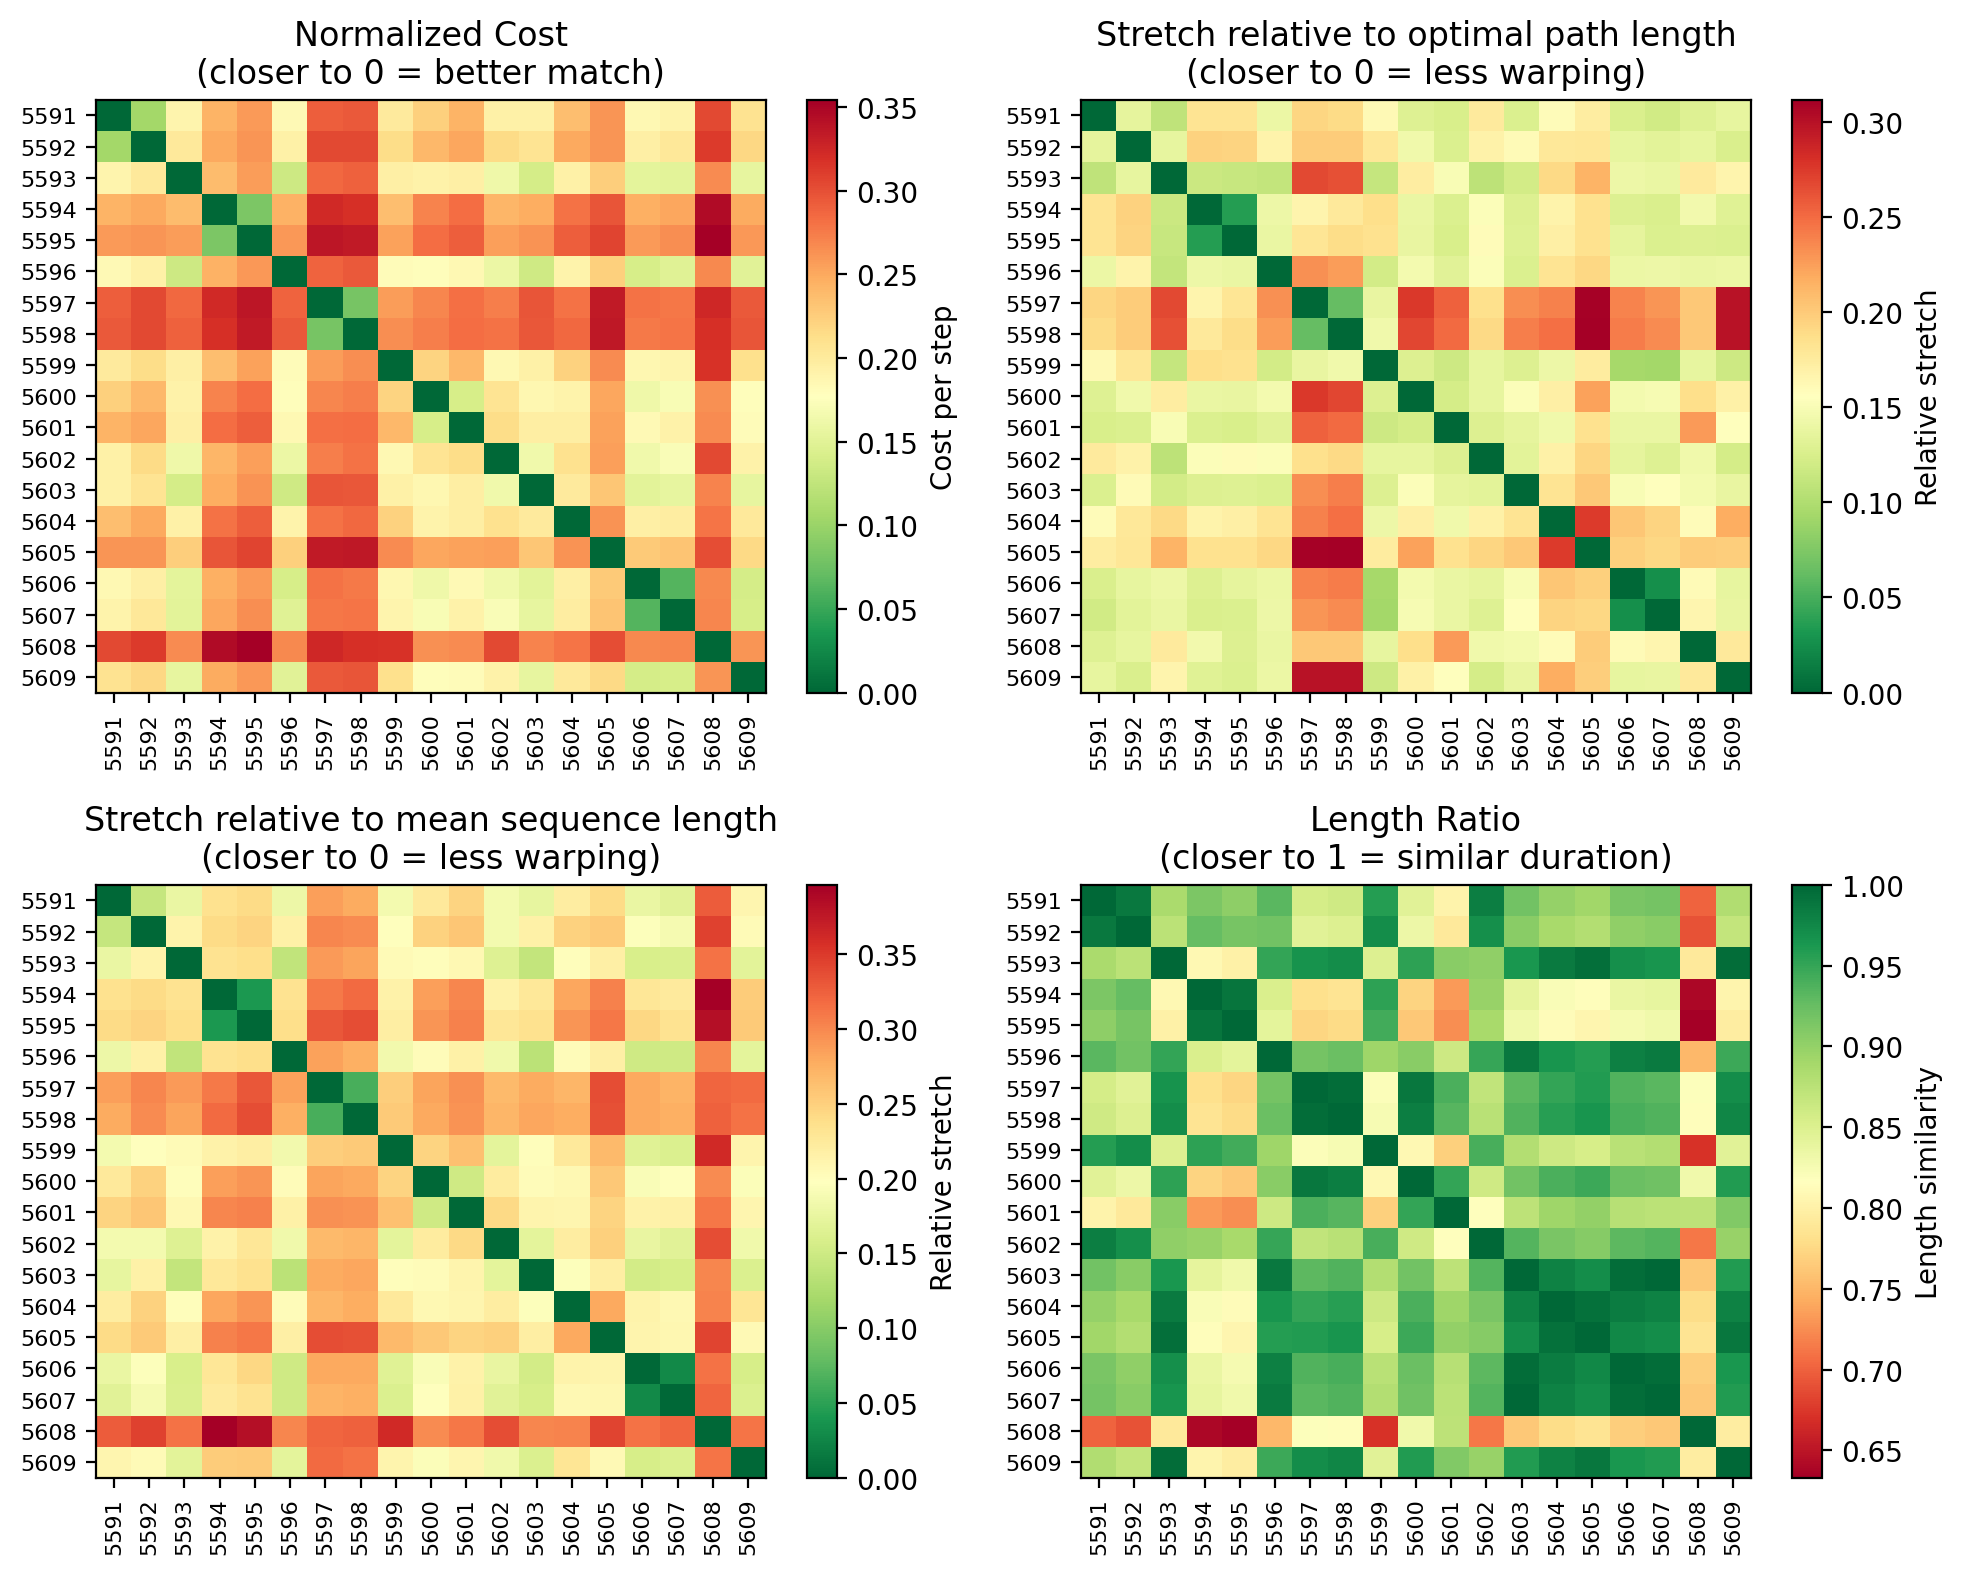

In [10]:
cluster_dir = composer_id_folder / '3_cluster'
os.makedirs(cluster_dir, exist_ok=True)

items, cost_mat, stretch_opt_mat, stretch_avg_mat, length_ratio_mat = compute_pairwise_features(align_df)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Flatten axes for convenience
axes = axes.ravel()

# helper to set ticks + labels
def set_ticks(ax, items):
    ax.set_xticks(range(len(items)))
    ax.set_xticklabels(items, rotation=90, fontsize=8)
    ax.set_yticks(range(len(items)))
    ax.set_yticklabels(items, fontsize=8)

# Cost Matrix
im1 = axes[0].imshow(cost_mat, cmap='RdYlGn_r', aspect='auto')
axes[0].set_title('Normalized Cost\n(closer to 0 = better match)', fontsize=12)
set_ticks(axes[0], items)
plt.colorbar(im1, ax=axes[0], label='Cost per step')

# Stretch Matrix (relative to optimal path)
im2 = axes[1].imshow(stretch_opt_mat, cmap='RdYlGn_r', aspect='auto')
axes[1].set_title('Stretch relative to optimal path length\n(closer to 0 = less warping)',
                  fontsize=12)
set_ticks(axes[1], items)
plt.colorbar(im2, ax=axes[1], label='Relative stretch')

# Stretch Matrix (relative to mean length)
im3 = axes[2].imshow(stretch_avg_mat, cmap='RdYlGn_r', aspect='auto')
axes[2].set_title('Stretch relative to mean sequence length\n(closer to 0 = less warping)',
                  fontsize=12)
set_ticks(axes[2], items)
plt.colorbar(im3, ax=axes[2], label='Relative stretch')

# Length Ratio Matrix
im4 = axes[3].imshow(length_ratio_mat, cmap='RdYlGn', aspect='auto')
axes[3].set_title('Length Ratio\n(closer to 1 = similar duration)', fontsize=12)
set_ticks(axes[3], items)
plt.colorbar(im4, ax=axes[3], label='Length similarity')

plt.tight_layout()

out_path = cluster_dir / 'feature_matrices.svg'
os.makedirs(out_path.parent, exist_ok=True)
plt.savefig(out_path)


## Clustering

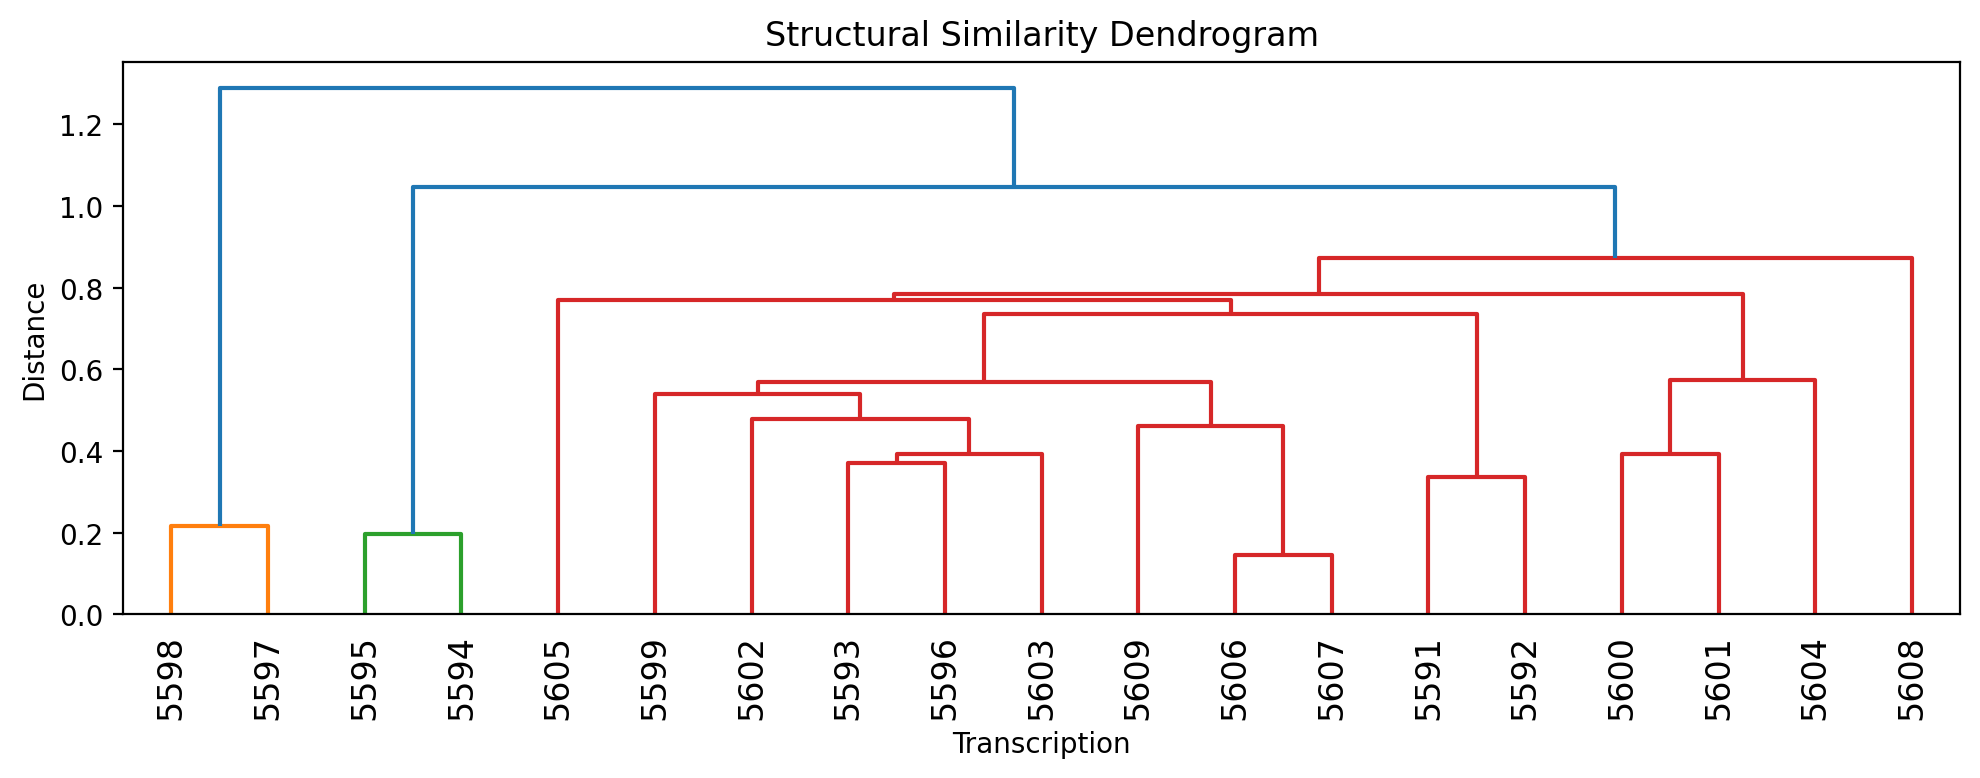

In [11]:
out_path = cluster_dir / 'dendrogram.svg'
os.makedirs(out_path.parent, exist_ok=True)
pred_groups, linkage_matrix, dist_matrix = hierarchical_structural_clustering(
                                            align_df, 
                                            method='ward', 
                                            cost_weight=2.0, 
                                            stretch_opt_weight=0.7,
                                            stretch_avg_weight=0.3,
                                            length_ratio_weight=0, 
                                            dist_thresh=0.7,
                                            plot=out_path)

In [12]:
print('predicted groups:')
for g, gi in pred_groups.items():
    print(g, gi)
print()

predicted groups:
group_1 [5597, 5598]
group_2 [5594, 5595]
group_3 [5593, 5596, 5599, 5602, 5603, 5606, 5607, 5609]
group_4 [5591, 5592]
group_5 [5605]
group_6 [5600, 5601, 5604]
group_7 [5608]



## Cluster Evaluation

Load pseudo labels

In [13]:
pseudo_labels = cluster_dir / 'pseudo_repeat_labels.csv'
estimated_groups = group_by_structure(pd.read_csv(pseudo_labels), structure_column='structure')
assert sum([len(v) for v in pred_groups.values()]) == sum([len(v) for v in estimated_groups.values()])
print('pseudo labels:')
for g,v in estimated_groups.items(): 
    print(g, v)
print()

true_labels = cluster_dir / 'correct_repeat_labels.csv'
if os.path.exists(true_labels):
    true_groups = group_by_structure(pd.read_csv(true_labels), structure_column='structure_correct')
    assert sum([len(v) for v in pred_groups.values()]) == sum([len(v) for v in true_groups.values()])
    print('true groups:')
    for g, gi in true_groups.items():
        print(g, gi)
print()

pseudo labels:
group_0 [5591, 5592, 5593, 5594, 5595, 5599, 5602, 5603, 5606, 5607, 5609]
group_1 [5596]
group_2 [5604]
group_3 [5600, 5601]
group_4 [5598]
group_5 [5597]
group_6 [5605]
group_7 [5608]

true groups:
group_0 [5605]
group_1 [5591, 5592, 5593, 5594, 5595, 5596, 5599, 5602, 5603, 5606, 5607, 5609]
group_2 [5604]
group_3 [5597, 5598]
group_4 [5600, 5601]
group_5 [5608]



Evaluate

In [14]:
print('Metrics:')
metrics = evaluate_clustering(estimated_groups, pred_groups)
for m in metrics:
    print(metrics[m], m)

Metrics:
0.3799 adjusted_rand_index
0.4873 adjusted_mutual_info
0.7761 homogeneity
0.6866 completeness
0.7286 v_measure
0.5333 pairwise_f1


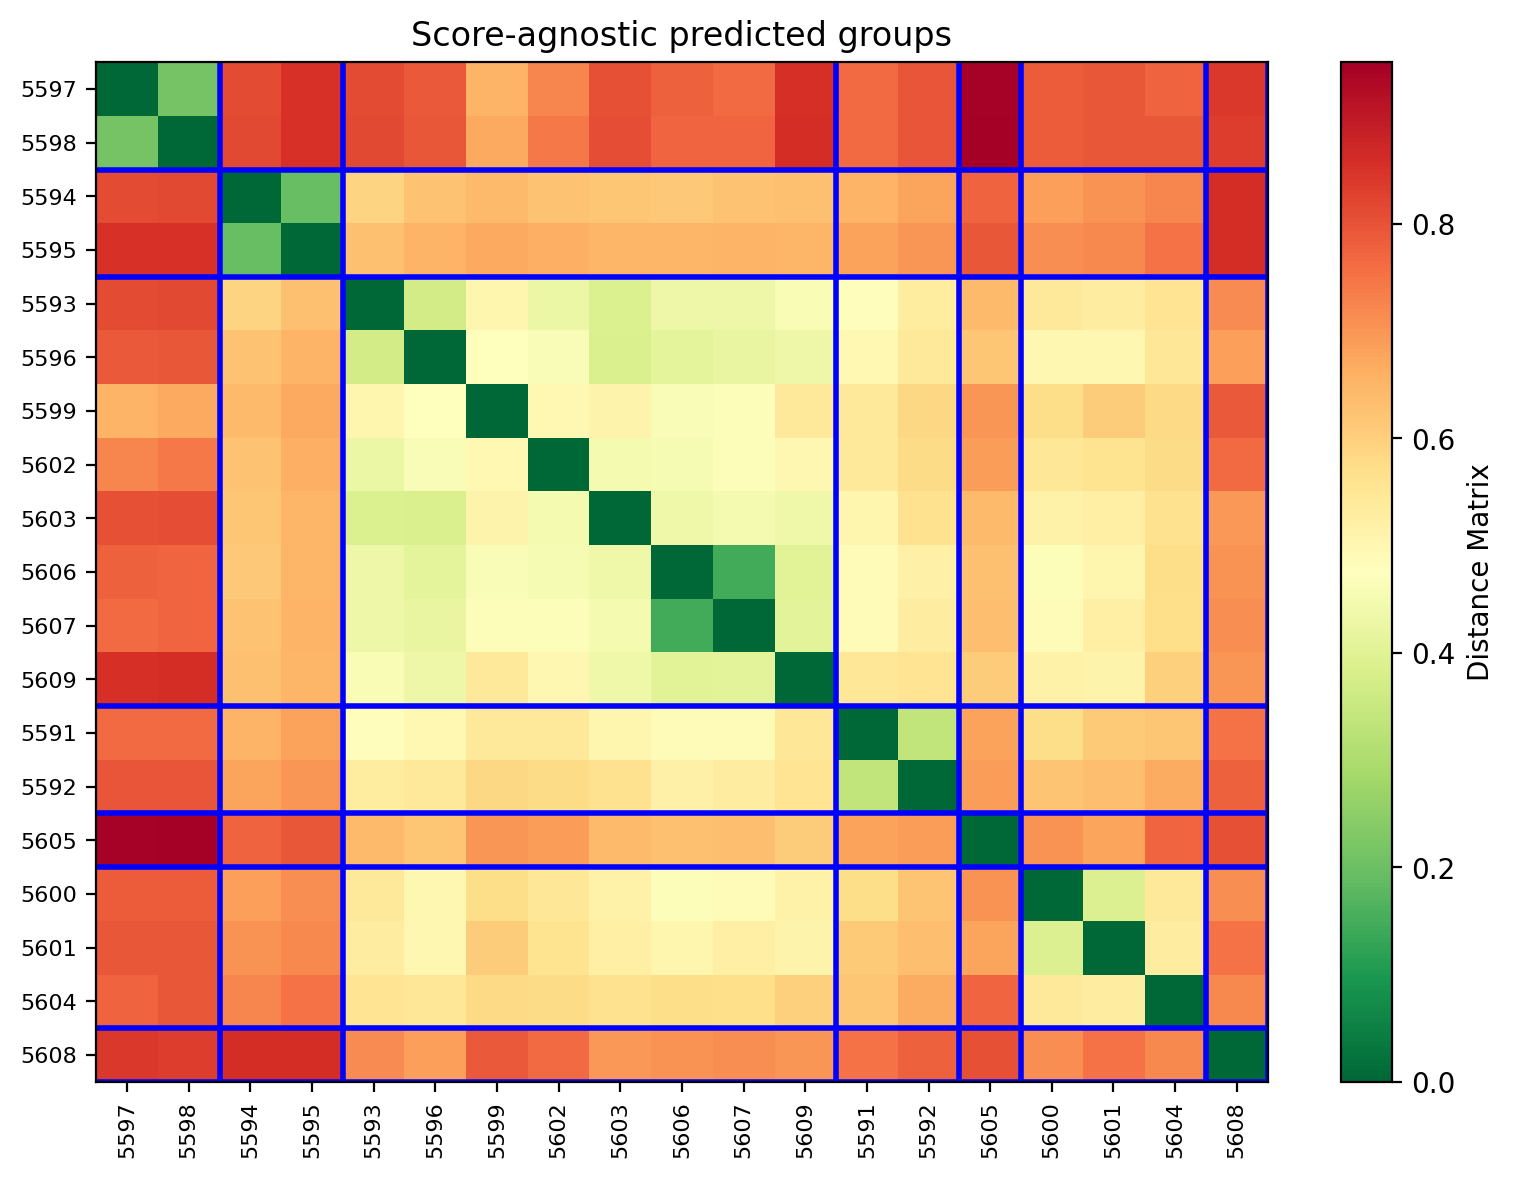

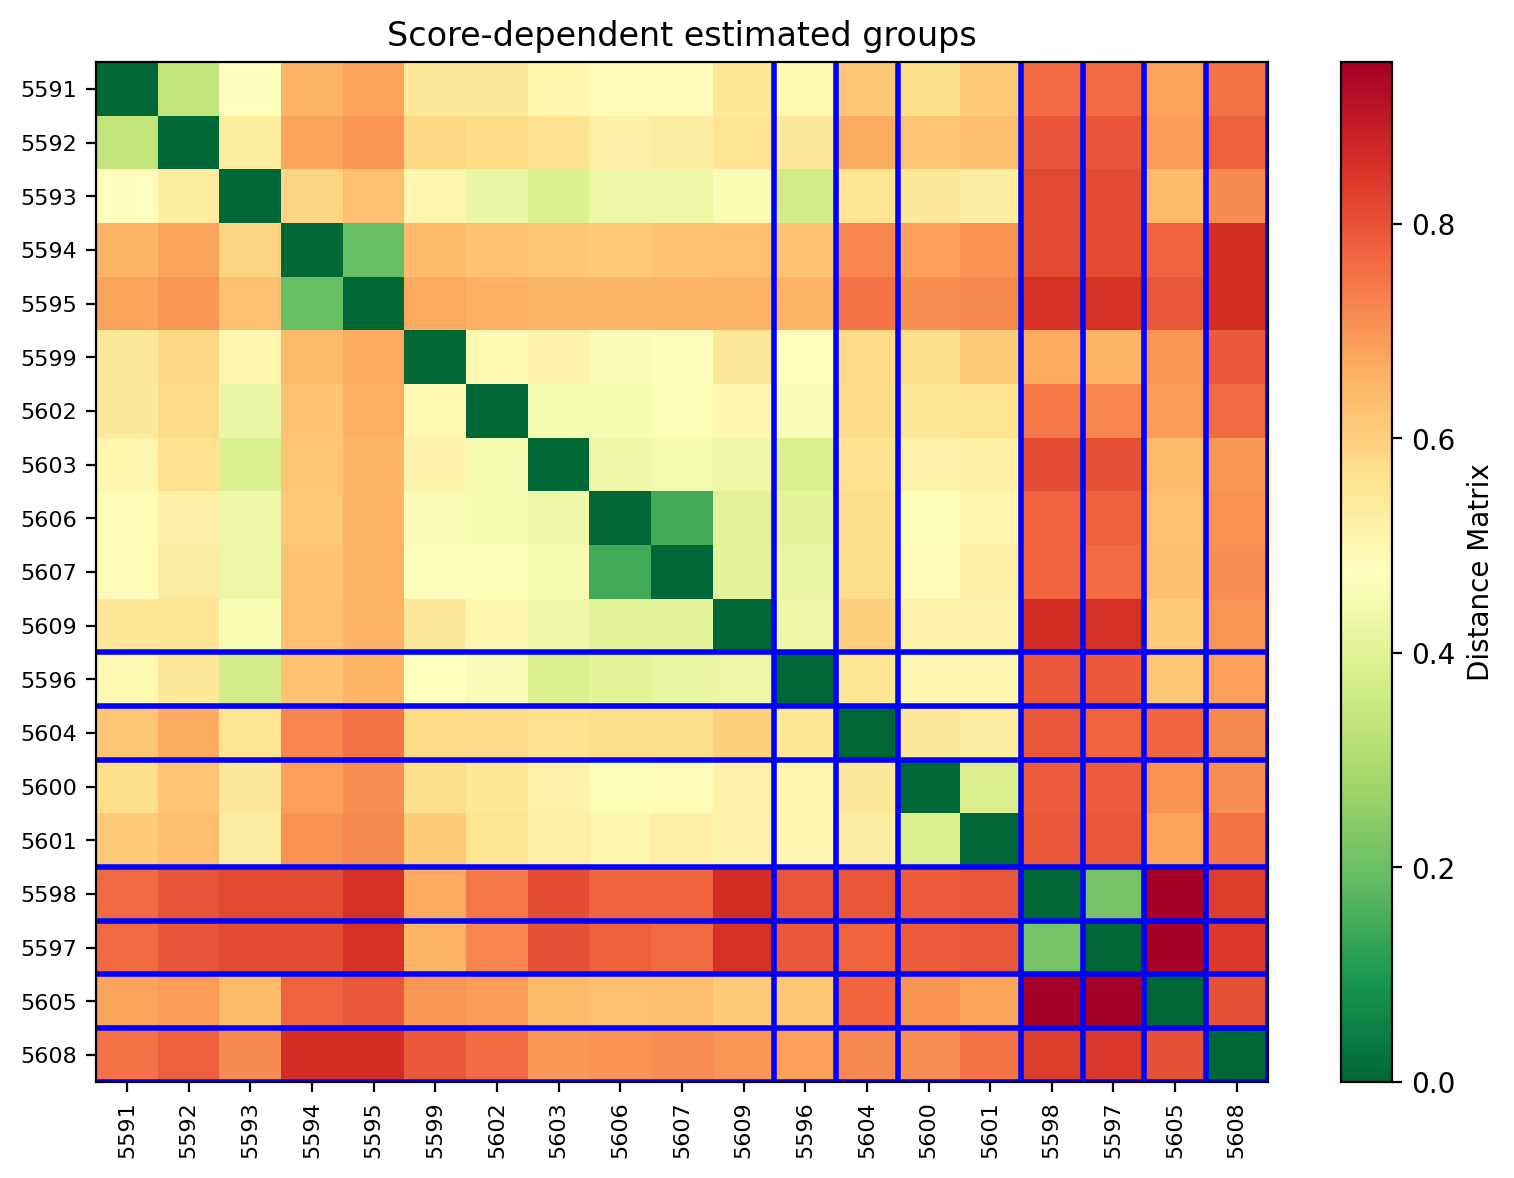

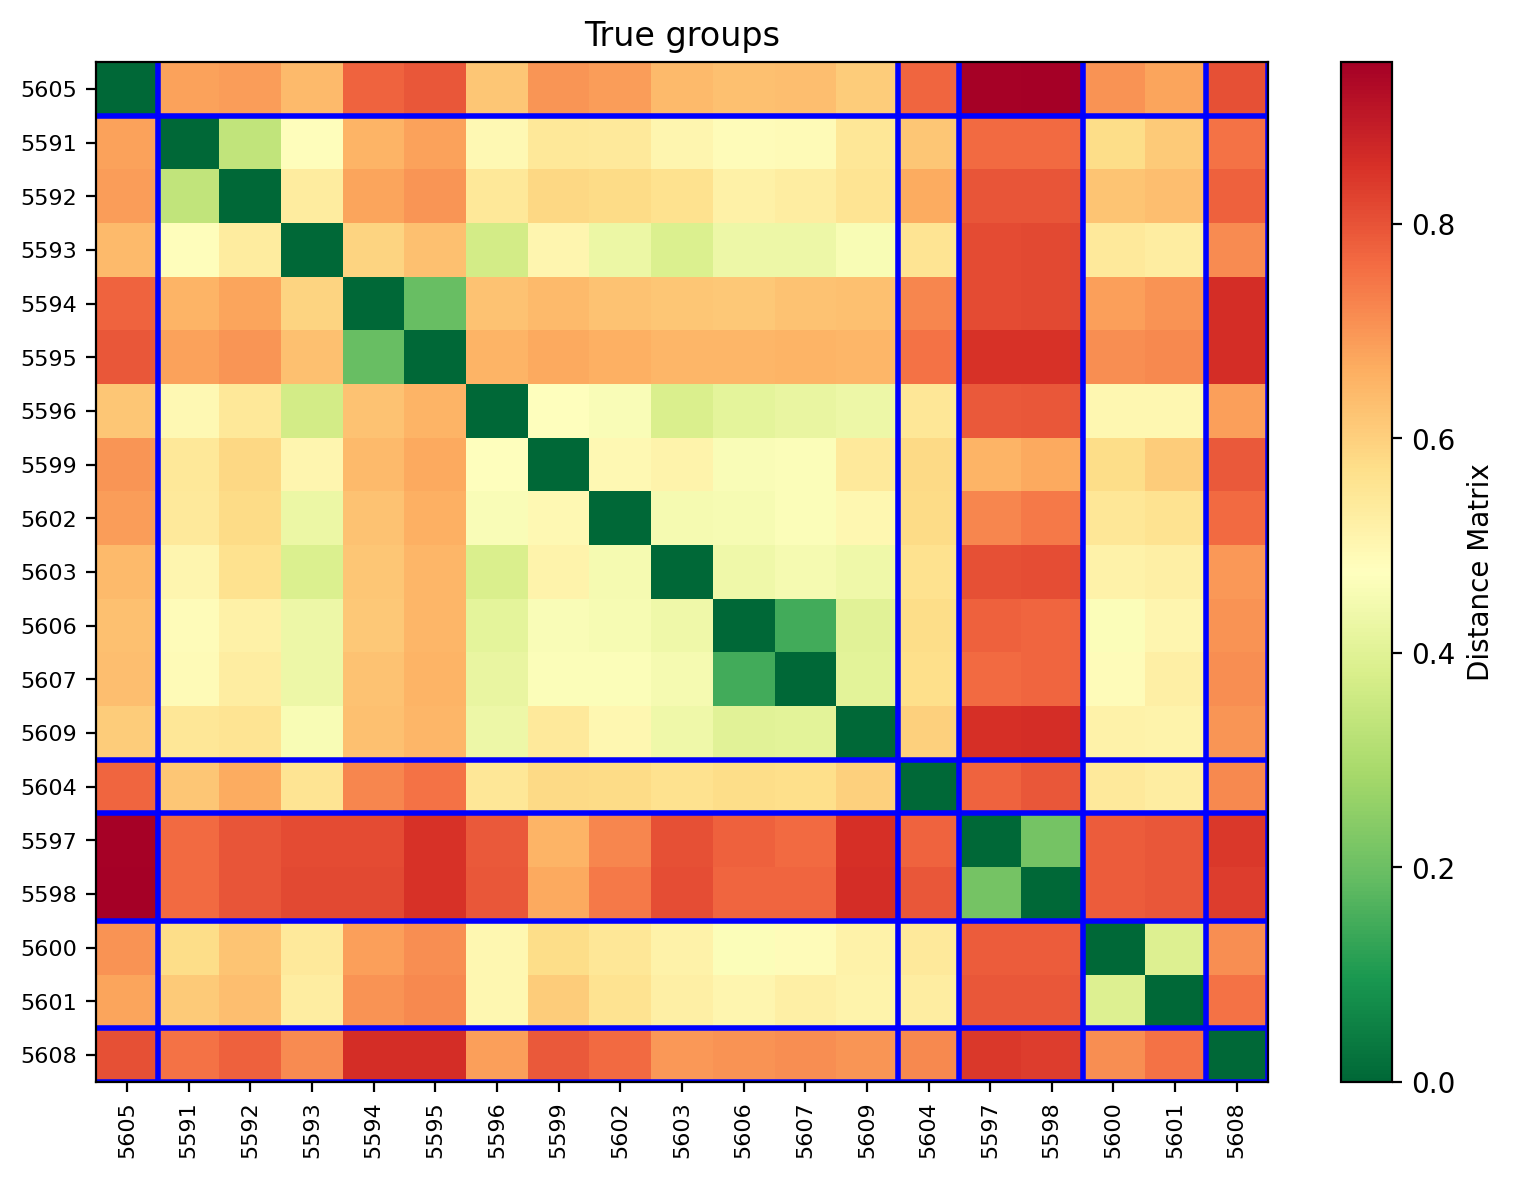

In [15]:
titles = ['Score-agnostic predicted groups', 'Score-dependent estimated groups', 'True groups']
groups = [pred_groups, estimated_groups, true_groups]
for title, group in zip(titles, groups):
    if title == 'Score-agnostic predicted groups':
        fig_title = 'cluster_pred'
    elif title == 'Score-dependent estimated groups':
        fig_title = 'score_est'
    elif title == 'True groups':
        fig_title = 'true_groups_'
    
    out_path = cluster_dir / f'dist_mat_{fig_title}.svg'
    plot_distance_matrix(items, dist_matrix, groups=group, title=title, figsize=(8,6), out=out_path)
    plot_distance_matrix(items, dist_matrix, groups=group, title=title, figsize=(8,6))

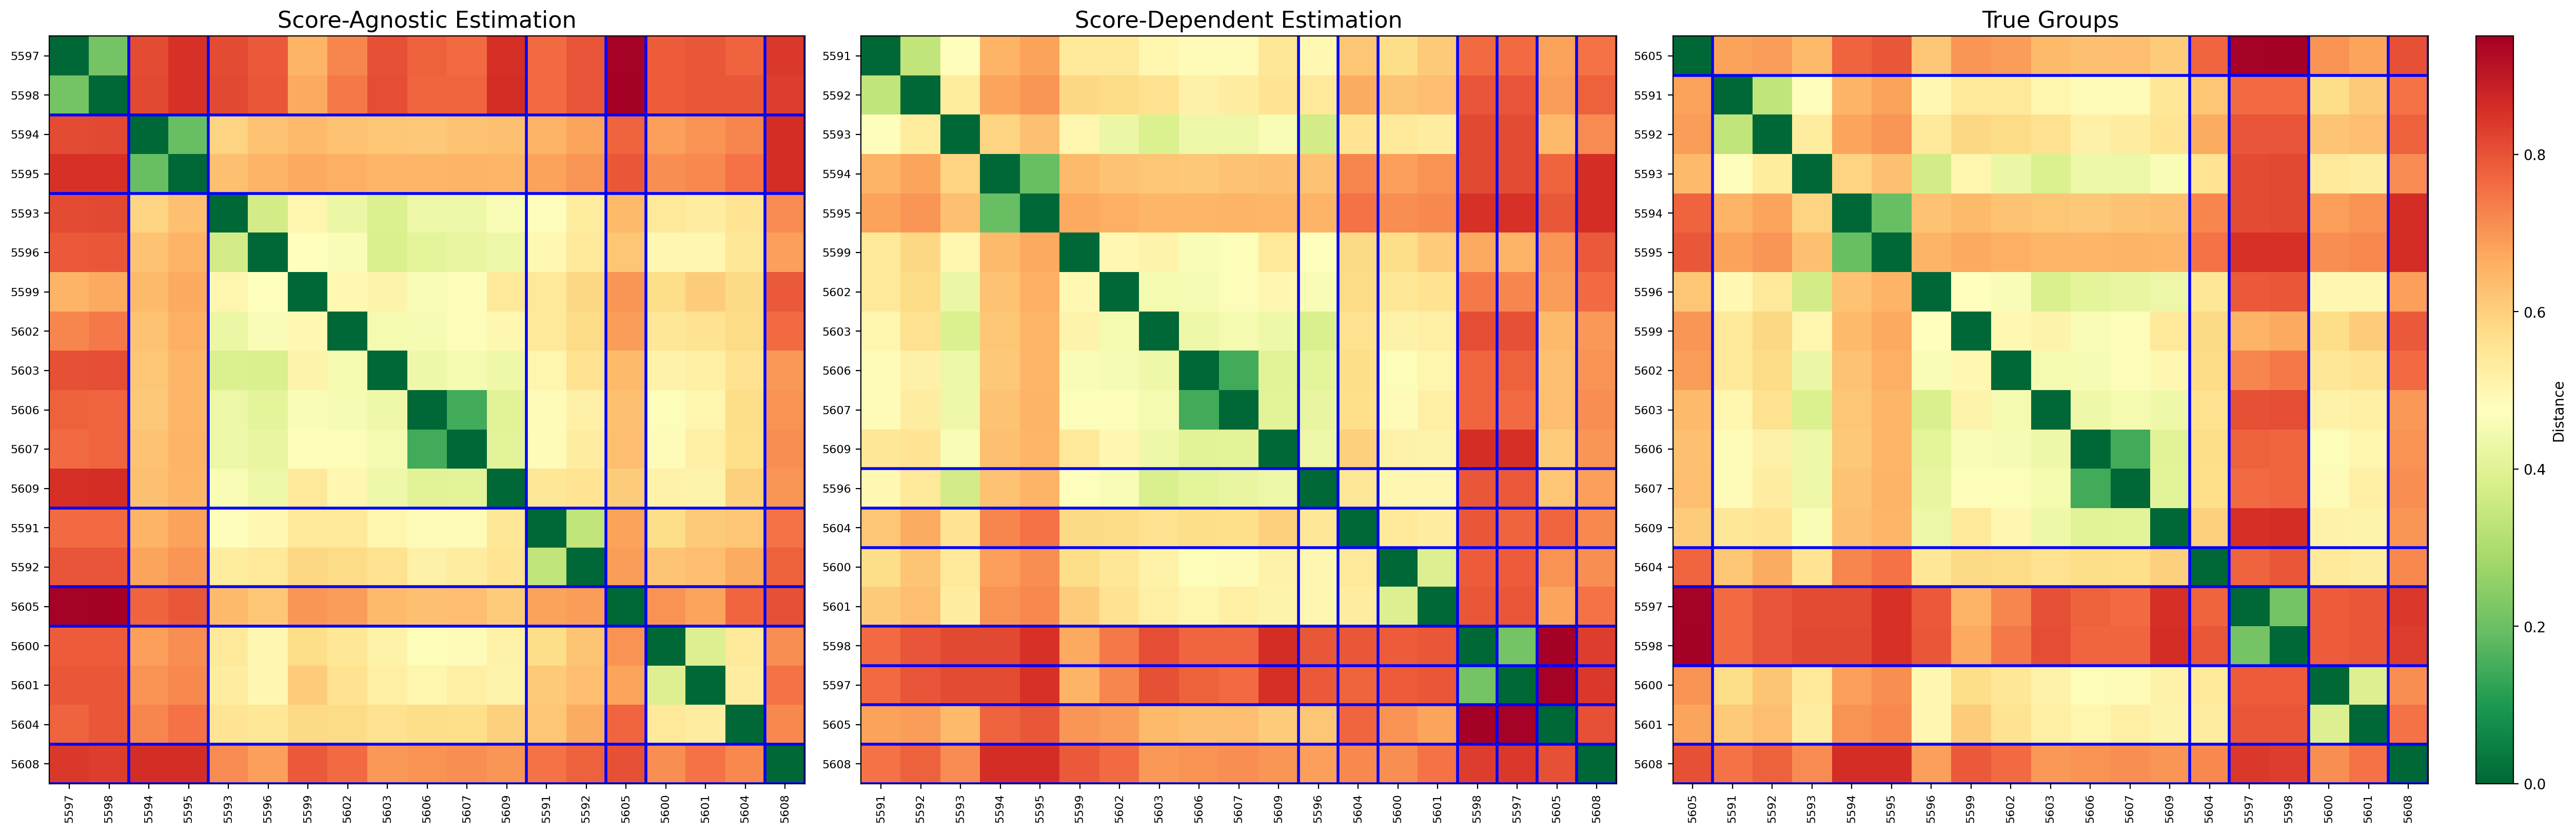

In [16]:
plot_n_dist_matrices(
    [items, items, items], 
    [dist_matrix, dist_matrix, dist_matrix],
    [{'predicted': pred_groups}, {'labels': estimated_groups}, {'true': true_groups}],
    ['Score-agnostic estimation', 'Score-dependent estimation', 'True groups'],
    out = cluster_dir / 'cluster-pred-vs-score-est-vs-true.svg'
)


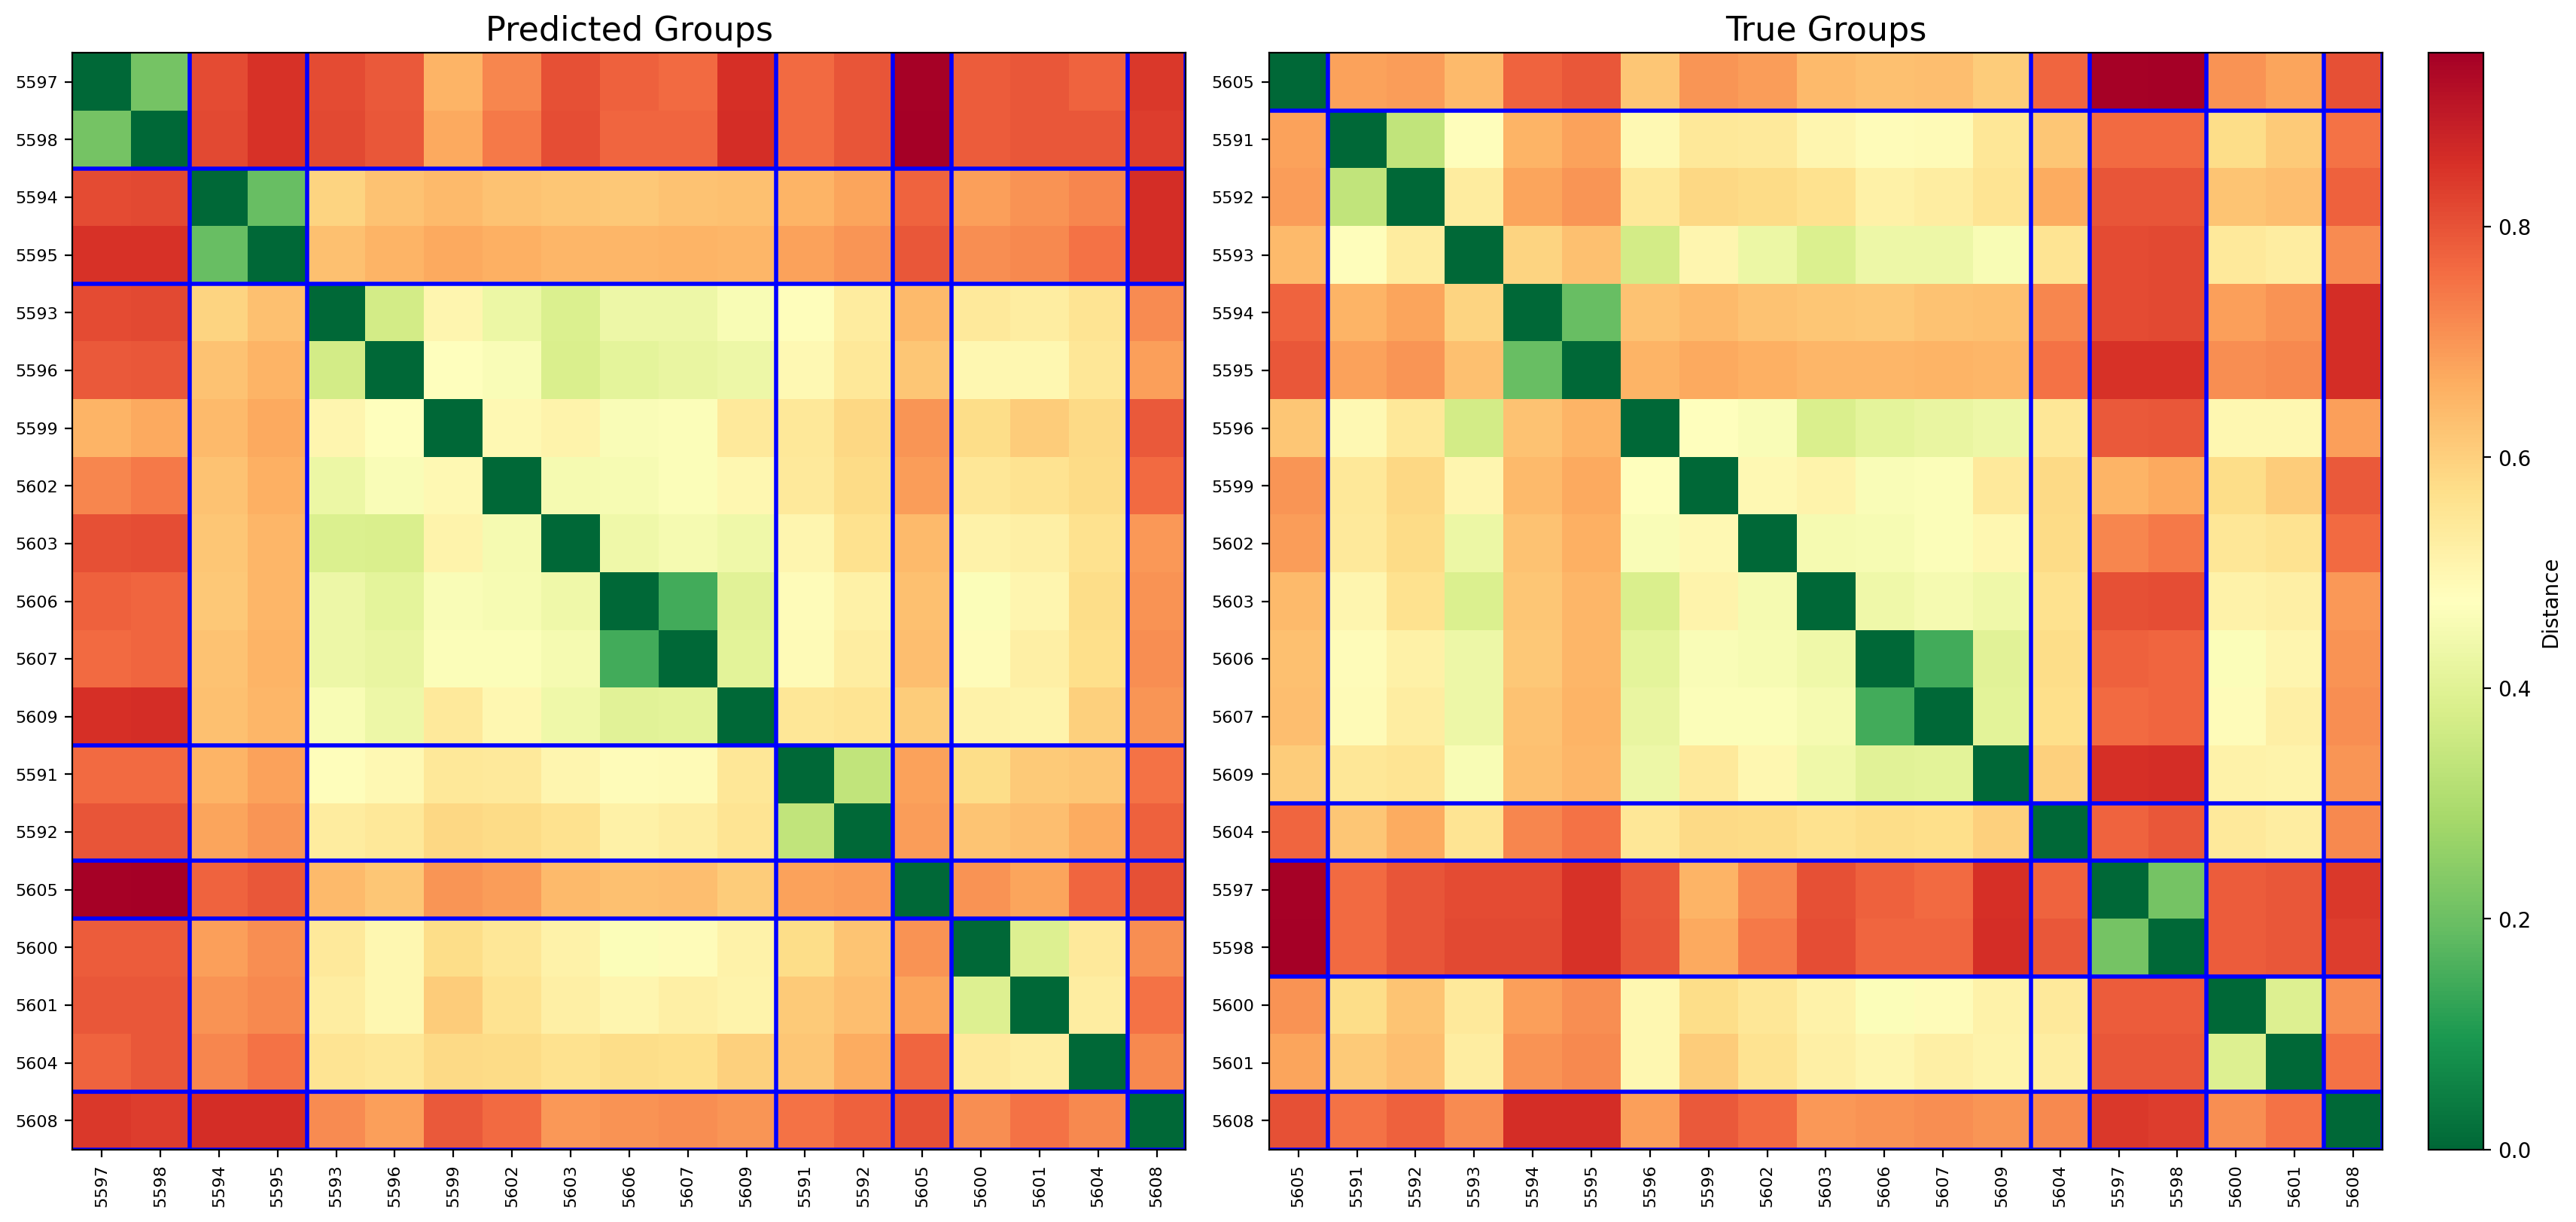

In [17]:
plot_n_dist_matrices(
    [items, items], 
    [dist_matrix, dist_matrix],
    [{'predicted': pred_groups}, {'true': true_groups}],
    ['Predicted groups', 'True groups'],
    out= cluster_dir /  f'cluster-pred-vs-true.svg'
)

## Grid search

In [19]:
start = time.perf_counter()
results_df = grid_search_clustering(
    align_df, 
    true_groups,
    methods=['complete', 'ward', 'average', 'weighted'],
    cost_weights=[0, 0.3,0.7, 1],
    stretch_opt_weight=[0, 0.3,0.7, 1],
    stretch_avg_weight=[0, 0.3,0.7, 1],
    length_weights=[0, 0.3,0.7, 1],
    dist_thresh=[0.7],
)
print(f"Execution time: {time.perf_counter() - start:.4f}s")

print("Top 10 parameter combinations:")
print(results_df.head(10))

Testing 1020 parameter combinations...


Grid search: 100%|██████████| 1020/1020 [00:11<00:00, 92.34it/s]

Execution time: 11.0546s
Top 10 parameter combinations:
       method  cost_weight  stretch_opt_weight  stretch_avg_weight  \
3    complete          0.0                 0.0                 0.3   
75   complete          0.3                 0.0                 1.0   
7    complete          0.0                 0.0                 0.7   
11   complete          0.0                 0.0                 1.0   
358      ward          0.3                 0.7                 0.7   
354      ward          0.3                 0.7                 0.3   
378      ward          0.3                 1.0                 1.0   
346      ward          0.3                 0.3                 1.0   
342      ward          0.3                 0.3                 0.7   
362      ward          0.3                 0.7                 1.0   

     length_weight  dist_thresh  n_predicted_groups  adjusted_rand_index  \
3              0.0          0.7                   5               0.9757   
75             0.0   